# AZ80 Cast-Forged Magnesium Alloy — Conditional DDPM: Training Notebook

**Paper:** E. Azqadan, H. Jahed, A. Arami, "Predictive microstructure image generation using denoising diffusion probabilistic models," *Acta Materialia*, 261 (2023) 119406. https://doi.org/10.1016/j.actamat.2023.119406

This notebook trains, **from randomly initialized weights**, the conditional Denoising Diffusion Probabilistic Model (DDPM) described above, to generate SEM microstructure images of cast-forged AZ80 magnesium alloy components. The model is conditioned on seven process parameters: cast geometry, metallography sample location, casting cooling rate, pre-forging soaking process, pre-forging heat treatment, forging temperature, and image magnification (paper Sections 2.1–2.2).

This is the **training** counterpart to the original `az80-image-generation.ipynb`, which only ran inference from a pre-trained checkpoint. The model architecture (`UNet_conditional`, `Down`/`Up`, `SelfAttention`, `EMA`) and diffusion math (`Diffusion`) below reproduce `modules.py` / `utils.py` / `ddpm.py` from this repository; only the notebook wrapper (data loading, training loop, checkpointing, sampling) is new.

This is the **Google Colab** variant of `az80-image-generation.ipynb` (that notebook targets Kaggle). The model/diffusion/training code is identical; only data loading (Google Drive instead of a Kaggle dataset input) and checkpoint/model storage (Drive instead of Kaggle's working directory) differ, since Colab and Kaggle mount external storage differently.

> **Note on `modules.py`/`ddpm.py`:** those two files reference the condition-vocabulary constants (`shapes`, `locations`, ...) as bare globals that are only ever defined in `ddpm.py`, not in `modules.py` itself — so `import modules; modules.UNet_conditional(...)` raises `NameError` unless something patches those names into `modules`'s namespace first. `image_generator.py` avoids this by being fully self-contained (one file, one namespace). This notebook follows that same self-contained pattern rather than importing `modules`/`utils`.

## How to run this notebook on Google Colab

1. **Upload the dataset to Google Drive.** Put a folder there that mirrors this repo's `data/` layout — `Training/<series>/*.jpg`, `Testing/<series>/*.jpg`, `Training Labels.xlsx`, `Testing Labels.xlsx` — anywhere under **My Drive** (any folder name works; see the Data Loading section for how it's found).
2. **Open this notebook in Colab** (File → Upload notebook, or open it directly from GitHub: File → Open notebook → GitHub tab → `arhorri/Phase3` → `az80-image-generation-colab.ipynb`).
3. **Enable a GPU:** Runtime → Change runtime type → Hardware accelerator → GPU.
4. **Run the Setup cell first and authorize Drive access** when prompted — it calls `google.colab.drive.mount()`, which pops up a Google auth flow the first time.
5. Run the rest of the cells. `resolve_data_root()` (Data Loading section) searches your mounted Drive structurally for a folder containing `Training/` and `Testing/` subfolders, so it doesn't matter what you named it.
6. Checkpoints and the final model are written **into Drive** (`My Drive/az80_ddpm_outputs/` by default — see `DRIVE_OUTPUT_DIR` in the Training Configuration section), not to the Colab VM's local disk, so they survive a runtime disconnect/restart.
7. **Resuming across sessions is automatic:** `RESUME_FROM = 'auto'` (the default) picks up the latest checkpoint under `DRIVE_OUTPUT_DIR/checkpoints/` if one exists, so reconnecting a fresh Colab runtime and re-running the notebook continues training where it left off — no manual checkpoint path editing needed. This matters because Colab's free-tier GPU sessions are time-limited (a handful of hours, less if idle) and the paper's full run was 3600 iterations ("equivalent to more than 130 h of computation").

If you're running this locally instead (e.g. after `git clone git@github.com:arhorri/Phase3.git`, outside Colab), it automatically falls back to the `data/` folder at the repo root and to local `checkpoints/`/`models/` folders — no path changes needed.

## 1. Setup

Imports, device selection, and a reproducibility seed. Everything here is preinstalled on Colab's standard GPU runtime except `openpyxl` (needed by `pandas.read_excel` for the `*Labels.xlsx` files), which this cell installs if missing. This cell also mounts Google Drive, since the dataset and all outputs (checkpoints, final model) live there rather than on the Colab VM's ephemeral local disk.

In [2]:
import copy
import itertools
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

try:
    import openpyxl  # noqa: F401
except ImportError:
    import sys
    import subprocess
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'openpyxl'], check=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device} | IN_COLAB={IN_COLAB}')

SEED = 42


def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed()

Mounted at /content/drive
Using device: cuda | IN_COLAB=True


## 2. Model Architecture

`UNet_conditional` and its building blocks, reproduced from `modules.py`. Per Section 2.2.3 of the paper: a U-Net (Ronneberger et al.) predicts the noise εₜ at each timestep. The timestep is encoded with a Transformer sinusoidal positional embedding added at every down/up block (as in Nichol & Dhariwal). Process-parameter conditioning is done differently from standard class-conditioning: instead of adding one class embedding to the timestep embedding, **each of the 7 process parameters gets its own embedding, linearly projected to the spatial size of that block, and concatenated as an extra channel** at every down-sampling and up-sampling layer (Section 2.2.3, paragraph 2). That's why `Down`/`Up` below take `SHP, Loc, CR, SK, HT, FT, Mag` as forward arguments, not just `x` and `t`.

The commented-out `#x = self.saN(x)` / `#x1 = self.sa1(x1)` lines inside `UNet_conditional.forward` are carried over unchanged from `modules.py` — some self-attention blocks in the original implementation are instantiated but not actually called at inference/training time. We keep this exactly as shipped rather than "fixing" it, since it defines the trained checkpoint's exact architecture.

**One deliberate deviation:** `SelfAttention2`/`SelfAttention4.forward()` call `self.mha(x_ln, x_ln, x_ln, need_weights=False)`, whereas `modules.py` omits `need_weights` (defaulting to `True`). The returned attention-weights tensor is discarded either way (`attention_value, _ = self.mha(...)`), but computing it forces PyTorch onto a slow path that materializes a full `(seq_len × seq_len)` matrix -- at the `as3` block's 128×128 resolution that's a 16,384×16,384 matrix per batch item per head, which OOMs a 15-16GB GPU at `batch_size=4`. `need_weights=False` routes to PyTorch's fused/flash-attention kernel (O(n) memory, mathematically identical output) instead. This changes memory use and speed only, not what the model computes.

In [3]:
# Cardinality of each of the 7 process-parameter conditions -- matches the
# 114/17-row class_table in ddpm.py and the process-parameter dictionaries in
# image_generator.py:
#   shape        in {cylinder, pre-form}                        -> 2
#   location     in {tall, web, short}                          -> 3
#   cooling rate in {1.5, 6, 10.4 C/s}                           -> 3
#   soaking      in {normal, 1.5h, 2h}                           -> 3
#   heat treat.  in {none, homogenization}                       -> 2
#   forging temp in {250, 300, 350 C}                            -> 3
#   magnification in {100x, 500x, 1000x, 1500x, 2000x, 3000x}    -> 6
shapes = 2
locations = 3
cooling_rates = 3
soaking_times = 3
heat_treatments = 2
forging_temps = 3
magnifications = 6
embedding_dim = 100


class EMA:
    """Exponential moving average of model weights (utils.py)."""

    def __init__(self, beta):
        super().__init__()
        self.beta = beta
        self.step = 0

    def update_model_average(self, ma_model, current_model):
        for current_params, ma_params in zip(current_model.parameters(), ma_model.parameters()):
            old_weight, up_weight = ma_params.data, current_params.data
            ma_params.data = self.update_average(old_weight, up_weight)

    def update_average(self, old, new):
        if old is None:
            return new
        return old * self.beta + (1 - self.beta) * new

    def step_ema(self, ema_model, model, step_start_ema=2000):
        if self.step < step_start_ema:
            self.reset_parameters(ema_model, model)
            self.step += 1
            return
        self.update_model_average(ema_model, model)
        self.step += 1

    def reset_parameters(self, ema_model, model):
        ema_model.load_state_dict(model.state_dict())


class SelfAttention2(nn.Module):
    def __init__(self, channels, size):
        super(SelfAttention2, self).__init__()
        self.channels = channels
        self.size = size
        self.mha = nn.MultiheadAttention(channels, 2, batch_first=True)
        self.ln = nn.LayerNorm([channels])
        self.ff_self = nn.Sequential(
            nn.LayerNorm([channels]),
            nn.Linear(channels, channels),
            nn.GELU(),
            nn.Linear(channels, channels),
        )

    def forward(self, x):
        x = x.view(-1, self.channels, self.size * self.size).swapaxes(1, 2)
        x_ln = self.ln(x)
        # need_weights=False: the attention-weights return value is unused
        # (discarded as `_` below either way) but computing it materializes
        # a full (seq_len x seq_len) matrix -- 16384x16384 at this block's
        # largest resolution, ~1GB per (batch, head) in fp32. Skipping it
        # routes PyTorch to its fused/flash-attention kernel (O(n) memory)
        # instead of the explicit O(n^2) matrix, with identical output.
        attention_value, _ = self.mha(x_ln, x_ln, x_ln, need_weights=False)
        attention_value = attention_value + x
        attention_value = self.ff_self(attention_value) + attention_value
        return attention_value.swapaxes(2, 1).view(-1, self.channels, self.size, self.size)


class SelfAttention4(nn.Module):
    def __init__(self, channels, size):
        super(SelfAttention4, self).__init__()
        self.channels = channels
        self.size = size
        self.mha = nn.MultiheadAttention(channels, 4, batch_first=True)
        self.ln = nn.LayerNorm([channels])
        self.ff_self = nn.Sequential(
            nn.LayerNorm([channels]),
            nn.Linear(channels, channels),
            nn.GELU(),
            nn.Linear(channels, channels),
        )

    def forward(self, x):
        x = x.view(-1, self.channels, self.size * self.size).swapaxes(1, 2)
        x_ln = self.ln(x)
        # need_weights=False: the attention-weights return value is unused
        # (discarded as `_` below either way) but computing it materializes
        # a full (seq_len x seq_len) matrix -- 16384x16384 at this block's
        # largest resolution, ~1GB per (batch, head) in fp32. Skipping it
        # routes PyTorch to its fused/flash-attention kernel (O(n) memory)
        # instead of the explicit O(n^2) matrix, with identical output.
        attention_value, _ = self.mha(x_ln, x_ln, x_ln, need_weights=False)
        attention_value = attention_value + x
        attention_value = self.ff_self(attention_value) + attention_value
        return attention_value.swapaxes(2, 1).view(-1, self.channels, self.size, self.size)


class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels, mid_channels=None, residual=False):
        super().__init__()
        self.residual = residual
        if not mid_channels:
            mid_channels = out_channels
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=3, padding=1, bias=False),
            nn.GroupNorm(1, mid_channels),
            nn.GELU(),
            nn.Conv2d(mid_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.GroupNorm(1, out_channels),
        )

    def forward(self, x):
        if self.residual:
            return F.gelu(x + self.double_conv(x))
        else:
            return self.double_conv(x)


class Down(nn.Module):
    def __init__(self, in_channels, out_channels, imsize, emb_dim=512):
        super().__init__()
        self.imsize = imsize
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, in_channels, residual=True),
            DoubleConv(in_channels, (out_channels - 7)),
        )
        self.emb_layer = nn.Sequential(
            nn.SiLU(),
            nn.Linear(emb_dim, out_channels),
        )
        self.SHP_label = nn.Sequential(
            nn.Embedding(shapes, embedding_dim), nn.Linear(embedding_dim, 1 * self.imsize * self.imsize))
        self.Loc_label = nn.Sequential(
            nn.Embedding(locations, embedding_dim), nn.Linear(embedding_dim, 1 * self.imsize * self.imsize))
        self.CR_label = nn.Sequential(
            nn.Embedding(cooling_rates, embedding_dim), nn.Linear(embedding_dim, 1 * self.imsize * self.imsize))
        self.SK_label = nn.Sequential(
            nn.Embedding(soaking_times, embedding_dim), nn.Linear(embedding_dim, 1 * self.imsize * self.imsize))
        self.HT_label = nn.Sequential(
            nn.Embedding(heat_treatments, embedding_dim), nn.Linear(embedding_dim, 1 * self.imsize * self.imsize))
        self.FT_label = nn.Sequential(
            nn.Embedding(forging_temps, embedding_dim), nn.Linear(embedding_dim, 1 * self.imsize * self.imsize))
        self.Mag_label = nn.Sequential(
            nn.Embedding(magnifications, embedding_dim), nn.Linear(embedding_dim, 1 * self.imsize * self.imsize))

    def forward(self, x, t, SHP, Loc, CR, SK, HT, FT, Mag):
        x = self.maxpool_conv(x)
        emb = self.emb_layer(t)[:, :, None, None].repeat(1, 1, x.shape[-2], x.shape[-1])
        shpemb = self.SHP_label(SHP).view(x.shape[0], 1, x.shape[-2], x.shape[-1])
        locemb = self.Loc_label(Loc).view(x.shape[0], 1, x.shape[-2], x.shape[-1])
        cremb = self.CR_label(CR).view(x.shape[0], 1, x.shape[-2], x.shape[-1])
        skemb = self.SK_label(SK).view(x.shape[0], 1, x.shape[-2], x.shape[-1])
        htemb = self.HT_label(HT).view(x.shape[0], 1, x.shape[-2], x.shape[-1])
        ftemb = self.FT_label(FT).view(x.shape[0], 1, x.shape[-2], x.shape[-1])
        magemb = self.Mag_label(Mag).view(x.shape[0], 1, x.shape[-2], x.shape[-1])
        x = torch.cat((x, shpemb, locemb, cremb, skemb, htemb, ftemb, magemb), dim=1)
        return x + emb


class Up(nn.Module):
    def __init__(self, in_channels, out_channels, imsize, emb_dim=512):
        super().__init__()
        self.imsize = imsize
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv = nn.Sequential(
            DoubleConv(in_channels, in_channels, residual=True),
            DoubleConv(in_channels, out_channels - 7, in_channels // 2),
        )
        self.emb_layer = nn.Sequential(
            nn.SiLU(),
            nn.Linear(emb_dim, out_channels),
        )
        self.SHP_label = nn.Sequential(
            nn.Embedding(shapes, embedding_dim), nn.Linear(embedding_dim, 1 * self.imsize * self.imsize))
        self.Loc_label = nn.Sequential(
            nn.Embedding(locations, embedding_dim), nn.Linear(embedding_dim, 1 * self.imsize * self.imsize))
        self.CR_label = nn.Sequential(
            nn.Embedding(cooling_rates, embedding_dim), nn.Linear(embedding_dim, 1 * self.imsize * self.imsize))
        self.SK_label = nn.Sequential(
            nn.Embedding(soaking_times, embedding_dim), nn.Linear(embedding_dim, 1 * self.imsize * self.imsize))
        self.HT_label = nn.Sequential(
            nn.Embedding(heat_treatments, embedding_dim), nn.Linear(embedding_dim, 1 * self.imsize * self.imsize))
        self.FT_label = nn.Sequential(
            nn.Embedding(forging_temps, embedding_dim), nn.Linear(embedding_dim, 1 * self.imsize * self.imsize))
        self.Mag_label = nn.Sequential(
            nn.Embedding(magnifications, embedding_dim), nn.Linear(embedding_dim, 1 * self.imsize * self.imsize))

    def forward(self, x, skip_x, t, SHP, Loc, CR, SK, HT, FT, Mag):
        x = self.up(x)
        x = torch.cat([skip_x, x], dim=1)
        x = self.conv(x)
        shpemb = self.SHP_label(SHP).view(x.shape[0], 1, x.shape[-2], x.shape[-1])
        locemb = self.Loc_label(Loc).view(x.shape[0], 1, x.shape[-2], x.shape[-1])
        cremb = self.CR_label(CR).view(x.shape[0], 1, x.shape[-2], x.shape[-1])
        skemb = self.SK_label(SK).view(x.shape[0], 1, x.shape[-2], x.shape[-1])
        htemb = self.HT_label(HT).view(x.shape[0], 1, x.shape[-2], x.shape[-1])
        ftemb = self.FT_label(FT).view(x.shape[0], 1, x.shape[-2], x.shape[-1])
        magemb = self.Mag_label(Mag).view(x.shape[0], 1, x.shape[-2], x.shape[-1])
        x = torch.cat((x, shpemb, locemb, cremb, skemb, htemb, ftemb, magemb), dim=1)
        emb = self.emb_layer(t)[:, :, None, None].repeat(1, 1, x.shape[-2], x.shape[-1])
        return x + emb


class UNet_conditional(nn.Module):
    def __init__(self, c_in=1, c_out=1, time_dim=512, num_classes=None):
        super().__init__()
        self.time_dim = time_dim
        self.inc = DoubleConv(c_in, 16)
        self.down1 = Down(16, 32, 256)
        self.sa1 = SelfAttention4(32, 256)
        self.down2 = Down(32, 64, 128)
        self.sa2 = SelfAttention4(64, 128)
        self.down3 = Down(64, 128, 64)
        self.sa3 = SelfAttention2(128, 64)
        self.down4 = Down(128, 256, 32)
        self.sa4 = SelfAttention4(256, 32)
        self.down5 = Down(256, 512, 16)
        self.sa5 = SelfAttention4(512, 16)
        self.down6 = Down(512, 512, 8)
        self.sa6 = SelfAttention4(512, 8)

        self.bot1 = DoubleConv(512, 512)
        self.bot2 = DoubleConv(512, 512)
        self.bot3 = DoubleConv(512, 512)

        self.up6 = Up(1024, 256, 16)
        self.as6 = SelfAttention4(256, 16)
        self.up5 = Up(512, 128, 32)
        self.as5 = SelfAttention4(128, 32)
        self.up4 = Up(256, 64, 64)
        self.as4 = SelfAttention4(64, 64)
        self.up3 = Up(128, 32, 128)
        self.as3 = SelfAttention2(32, 128)
        self.up2 = Up(64, 16, 256)
        self.as2 = SelfAttention4(16, 256)
        self.up1 = Up(32, 8, 512)
        self.as1 = SelfAttention4(8, 512)
        self.outc = nn.Conv2d(8, c_out, kernel_size=1)

    def pos_encoding(self, t, channels):
        inv_freq = 1.0 / (10000 ** (torch.arange(0, channels, 2).float().to(device) / channels))
        pos_enc_a = torch.sin(t.repeat(1, channels // 2) * inv_freq)
        pos_enc_b = torch.cos(t.repeat(1, channels // 2) * inv_freq)
        pos_enc = torch.cat([pos_enc_a, pos_enc_b], dim=-1)
        return pos_enc

    def forward(self, x, t, SHP, Loc, CR, SK, HT, FT, Mag):
        t = t.unsqueeze(-1).type(torch.float)
        t = self.pos_encoding(t, self.time_dim)

        x0 = self.inc(x)
        x1 = self.down1(x0, t, SHP, Loc, CR, SK, HT, FT, Mag)
        # x1 = self.sa1(x1)
        x2 = self.down2(x1, t, SHP, Loc, CR, SK, HT, FT, Mag)
        # x2 = self.sa2(x2)
        x3 = self.down3(x2, t, SHP, Loc, CR, SK, HT, FT, Mag)
        x3 = self.sa3(x3)
        x4 = self.down4(x3, t, SHP, Loc, CR, SK, HT, FT, Mag)
        x4 = self.sa4(x4)
        x5 = self.down5(x4, t, SHP, Loc, CR, SK, HT, FT, Mag)
        x5 = self.sa5(x5)
        x6 = self.down6(x5, t, SHP, Loc, CR, SK, HT, FT, Mag)
        x6 = self.sa6(x6)

        x6 = self.bot1(x6)
        x6 = self.bot2(x6)
        x6 = self.bot3(x6)

        x = self.up6(x6, x5, t, SHP, Loc, CR, SK, HT, FT, Mag)
        x = self.as6(x)
        x = self.up5(x, x4, t, SHP, Loc, CR, SK, HT, FT, Mag)
        x = self.as5(x)
        x = self.up4(x, x3, t, SHP, Loc, CR, SK, HT, FT, Mag)
        x = self.as4(x)
        x = self.up3(x, x2, t, SHP, Loc, CR, SK, HT, FT, Mag)
        x = self.as3(x)
        x = self.up2(x, x1, t, SHP, Loc, CR, SK, HT, FT, Mag)
        # x = self.as2(x)
        x = self.up1(x, x0, t, SHP, Loc, CR, SK, HT, FT, Mag)
        # x = self.as1(x)
        output = self.outc(x)
        return output

## 3. Diffusion Process

Forward (noising) and reverse (sampling) processes, Section 2.2.2 of the paper, reproduced from `utils.py`: `noise_steps=1000`, a linear beta schedule from `beta_start=1e-4` to `beta_end=0.02`. `sample()` supports classifier-free guidance via `cfg_scale`; the training loop below always calls it with `cfg_scale=0` (unconditional guidance term skipped), matching how it's called throughout `ddpm.py` / `image_generator.py`.

In [4]:
class Diffusion:
    def __init__(self, noise_steps=1000, beta_start=1e-4, beta_end=0.02, img_size=512):
        self.noise_steps = noise_steps
        self.beta_start = beta_start
        self.beta_end = beta_end
        self.img_size = img_size

        self.beta = self.prepare_noise_schedule().to(device)
        self.alpha = 1. - self.beta
        self.alpha_hat = torch.cumprod(self.alpha, dim=0)

    def prepare_noise_schedule(self):
        return torch.linspace(self.beta_start, self.beta_end, self.noise_steps)

    def noise_images(self, x, t):
        sqrt_alpha_hat = torch.sqrt(self.alpha_hat[t])[:, None, None, None]
        sqrt_one_minus_alpha_hat = torch.sqrt(1. - self.alpha_hat[t])[:, None, None, None]
        epsilon = torch.randn_like(x)
        return sqrt_alpha_hat * x + sqrt_one_minus_alpha_hat * epsilon, epsilon

    def sample_timesteps(self, n):
        return torch.randint(low=1, high=self.noise_steps, size=(n,))

    def sample(self, model, n, SHP, Loc, CR, SK, HT, FT, Mag, cfg_scale=0):
        model.eval()
        amp_enabled = torch.cuda.is_available()
        with torch.no_grad(), torch.amp.autocast('cuda', enabled=amp_enabled):
            x = torch.randn((n, 1, self.img_size, self.img_size)).to(device)
            for i in reversed(range(1, self.noise_steps)):
                t = (torch.ones(n) * i).long().to(device)
                predicted_noise = model(x, t, SHP, Loc, CR, SK, HT, FT, Mag)
                if cfg_scale > 0:
                    uncond_predicted_noise = model(x, t, None, None, None, None, None, None, None)
                    predicted_noise = torch.lerp(uncond_predicted_noise, predicted_noise, cfg_scale)
                alpha = self.alpha[t][:, None, None, None]
                alpha_hat = self.alpha_hat[t][:, None, None, None]
                beta = self.beta[t][:, None, None, None]
                if i > 1:
                    noise = torch.randn_like(x)
                else:
                    noise = torch.zeros_like(x)
                x = 1 / torch.sqrt(alpha) * (x - ((1 - alpha) / (torch.sqrt(1 - alpha_hat))) * predicted_noise) + torch.sqrt(beta) * noise
        model.train()
        return x.float()

## 4. Data Loading

**Primary source:** whichever folder under your mounted Google Drive (`/content/drive/MyDrive/`) structurally looks like this dataset (has `Training/` and `Testing/` subfolders) — see `resolve_data_root()` below. It does not have to be named any particular thing, and can be anywhere under My Drive (searched a couple of levels deep).
**Fallback source:** the `data/` folder at this repo's root (used automatically when nothing under Drive matches, e.g. running locally/outside Colab after `git clone`).

**Assumption (explicit):** we assume the Drive folder mirrors the structure already committed under `data/` in this repo:

```
<root>/Training/<series>/*.jpg        e.g. Training/CM01-0500/*.jpg
<root>/Testing/<series>/*.jpg         e.g. Testing/CM06-0500/*.jpg
<root>/Training Labels.xlsx
<root>/Testing Labels.xlsx
```

Each `*Labels.xlsx` has one row per field (`Label`, `Class`, `Shape`, `Location`, `Cooling rate`, `Soaking`, `Heat-treatment`, `Forging Temp`, `Magnification`) and one column per series — this is the exact layout of `data/Training Labels.xlsx` / `data/Testing Labels.xlsx` as shipped in this repo (verified by inspection), and also matches the `class_table` hardcoded in `ddpm.py`.

**Train/Test split — leave-one-category-out, 87:13 (Section 2.2.4):** the paper explicitly uses a leave-one-category-out split, holding out 17 of 131 image classes (~13%) as unseen test conditions. This is *exactly* what the `Training/` vs `Testing/` folders already encode: 114 training series vs 17 testing series, 114 / (114 + 17) ≈ 87.0%. So rather than drawing a new random split, we reuse the existing folder split directly — it already **is** the leave-one-category-out split the paper describes, at the series (not just image) level, so held-out conditions are genuinely unseen rather than merely different crops of a seen image.

In [5]:
# --- Data source resolution -------------------------------------------------
# Rather than require an exact Drive path, search structurally under My
# Drive for any folder that actually looks like this dataset (has Training/
# and Testing/ subfolders), a couple of levels deep, plus a local `data/`
# fallback for running off a repo clone outside Colab. Put the dataset
# anywhere under My Drive -- it doesn't matter what you name the folder.
DRIVE_ROOT = Path('/content/drive/MyDrive')
DRIVE_SEARCH_DEPTH = 2  # how many folder levels under My Drive to search --
                        # kept shallow since a personal Drive can have many
                        # unrelated folders and Drive-mounted I/O is slow;
                        # raise it if your dataset is nested deeper.


def _looks_like_dataset_root(c: Path) -> bool:
    return (
        c.is_dir()
        and (c / 'Training').is_dir()
        and (c / 'Testing').is_dir()
        and (c / 'Training Labels.xlsx').is_file()
        and (c / 'Testing Labels.xlsx').is_file()
    )


def resolve_data_root() -> Path:
    candidates = []
    if DRIVE_ROOT.exists():
        level = [DRIVE_ROOT]
        for _ in range(DRIVE_SEARCH_DEPTH):
            next_level = []
            for d in level:
                if d.is_dir():
                    next_level.extend(p for p in d.iterdir() if p.is_dir())
            candidates.extend(next_level)
            level = next_level
    candidates += [Path('data')]  # local clone fallback (outside Colab)

    # Require Training/, Testing/, and both *Labels.xlsx to all be present --
    # matching on Training/+Testing/ alone can grab an unrelated or
    # incomplete folder that happens to share those subfolder names (e.g. a
    # stray/partial upload sitting elsewhere in the same Drive).
    matches = [c for c in candidates if _looks_like_dataset_root(c)]
    if not matches:
        # Fall back to the looser check only to give a more informative
        # error message about what's actually missing, if anything close
        # was found.
        near_matches = [c for c in candidates if c.is_dir() and (c / 'Training').is_dir() and (c / 'Testing').is_dir()]
        if near_matches:
            missing = [
                f"{c} (missing: {', '.join(n for n in ['Training Labels.xlsx', 'Testing Labels.xlsx'] if not (c / n).is_file())})"
                for c in near_matches
            ]
            raise FileNotFoundError(
                "Found folder(s) with Training/ and Testing/ but missing the label "
                f"xlsx files: {missing}. Fix the folder's contents, or move/rename "
                "the incomplete one so it isn't found first."
            )
        raise FileNotFoundError(
            "Could not find a data root. Upload a dataset folder to Google Drive "
            "that mirrors data/'s layout (Training/, Testing/, *Labels.xlsx) "
            "somewhere under My Drive, or run this notebook from a clone of the "
            "repo with a 'data/' folder present at the root."
        )
    if len(matches) > 1:
        print(f'Warning: multiple candidate dataset folders found: {matches}. Using the first: {matches[0]}')
    print(f'Using data root: {matches[0].resolve()}')
    return matches[0]


DATA_ROOT = resolve_data_root()
TRAIN_DIR = DATA_ROOT / 'Training'
TEST_DIR = DATA_ROOT / 'Testing'
TRAIN_LABELS_XLSX = DATA_ROOT / 'Training Labels.xlsx'
TEST_LABELS_XLSX = DATA_ROOT / 'Testing Labels.xlsx'

CONDITION_COLUMNS = ['shape', 'location', 'cooling_rate', 'soaking',
                     'heat_treatment', 'forging_temp', 'magnification']


def load_label_table(xlsx_path: Path) -> pd.DataFrame:
    """Parse a `<Training|Testing> Labels.xlsx` sheet (one row per field, one
    column per series -- see the Data Loading markdown above) into a
    DataFrame indexed by series name, e.g. table.loc['CM01-0500'].shape."""
    raw = pd.read_excel(xlsx_path, header=None).set_index(0)
    table = raw.T.reset_index(drop=True)
    table = table.rename(columns={
        'Label': 'series', 'Class': 'class_id', 'Shape': 'shape',
        'Location': 'location', 'Cooling rate': 'cooling_rate',
        'Soaking': 'soaking', 'Heat-treatment': 'heat_treatment',
        'Forging Temp': 'forging_temp', 'Magnification': 'magnification',
    })
    int_cols = ['class_id'] + CONDITION_COLUMNS
    table[int_cols] = table[int_cols].astype(int)
    return table.set_index('series')


class AZ80SeriesDataset(Dataset):
    """One sample = one SEM image + the 7 process-parameter labels of the
    series (folder) it belongs to. Series folders hold a variable number of
    images (a handful up to ~9 in this dataset)."""

    IMG_EXTS = {'.jpg', '.jpeg', '.png', '.tif', '.tiff', '.bmp'}

    def __init__(self, image_dir: Path, label_table: pd.DataFrame, crop_size: int = 512, augment: bool = False):
        self.label_table = label_table
        self.samples = []  # (path, series) pairs
        for series_dir in sorted(Path(image_dir).iterdir()):
            if not series_dir.is_dir() or series_dir.name not in label_table.index:
                continue
            for f in sorted(series_dir.iterdir()):
                if f.suffix.lower() in self.IMG_EXTS:
                    self.samples.append((f, series_dir.name))
        if not self.samples:
            raise RuntimeError(f'No labeled images found under {image_dir}')

        # Section 2.2.1: images are cropped to 512x512 "at the beginning of
        # each iteration" and normalized to [-1, 1] (matches whole_transform
        # in ddpm.py). pad_if_needed is a defensive addition not present in
        # the original code, in case a source image is smaller than 512px.
        self.base_transform = transforms.Compose([
            transforms.Grayscale(),
            transforms.RandomCrop(crop_size, pad_if_needed=True, padding_mode='reflect'),
            transforms.ToTensor(),
            transforms.Lambda(lambda t: (t * 2) - 1),
        ])
        # aug_transform in ddpm.py -- horizontal/vertical flip, p=0.5 each.
        self.aug_transform = transforms.Compose([
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.5),
        ]) if augment else None

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, series = self.samples[idx]
        image = Image.open(path).convert('RGB')
        image = self.base_transform(image)
        if self.aug_transform is not None:
            image = self.aug_transform(image)
        row = self.label_table.loc[series]
        cond = torch.tensor([int(row[c]) for c in CONDITION_COLUMNS], dtype=torch.long)
        return image, cond, series


train_labels = load_label_table(TRAIN_LABELS_XLSX)
test_labels = load_label_table(TEST_LABELS_XLSX)
n_total = len(train_labels) + len(test_labels)
print(f'{len(train_labels)} training series, {len(test_labels)} testing series '
      f'({len(train_labels) / n_total:.1%} / {len(test_labels) / n_total:.1%} split)')

train_dataset = AZ80SeriesDataset(TRAIN_DIR, train_labels, crop_size=512, augment=True)
test_dataset = AZ80SeriesDataset(TEST_DIR, test_labels, crop_size=512, augment=False)
print(f'{len(train_dataset)} training images, {len(test_dataset)} testing images')

BATCH_SIZE = 4
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=2, drop_last=True)

Using data root: /content/drive/MyDrive/Az80dataset
114 training series, 17 testing series (87.0% / 13.0% split)
399 training images, 38 testing images


## 5. Training Configuration

Optimizer, loss, EMA and checkpointing setup. Hyperparameters follow the paper and the original `ddpm.py`: Adam (`lr=3e-4`), MSE loss between true and predicted noise, batch size 4, EMA with `beta=0.995` and `step_start_ema=2000` (EMA tracking only starts contributing after 2000 optimizer steps; before that `ema_model` is just reset to `model`'s current weights every step).

`NUM_ITERATIONS` defaults to **3600**, matching the paper ("after 3600 iterations, equivalent to more than 130 h of computation ... training was stopped due to no further significant improvement in the FID score"). Training here is **iteration-based, not epoch-based** — we cycle through `train_loader` indefinitely, matching how the paper reports progress (Fig. 2 shows FID at iterations 30, 600, 1200, ..., 3600).

Since 130h won't fit in one Colab session, `RESUME_FROM = 'auto'` picks up the latest checkpoint under Drive automatically (see below) -- no manual checkpoint-path editing needed between sessions.

**Mixed precision (AMP):** `batch_size=4` at 512x512 with this architecture's `as3` block (full self-attention over a 128x128 = 16,384-token feature map) needs ~8GB just for that one attention matrix in fp32 -- easily OOMs a 15-16GB GPU once the rest of the U-Net's activations are counted. `scaler = torch.amp.GradScaler('cuda', ...)` here, paired with `torch.amp.autocast('cuda', ...)` in the training loop and in `Diffusion.sample()`, runs eligible ops in fp16 to roughly halve memory use so batch_size=4 fits. This is a deviation from the original `ddpm.py` (which used plain fp32 training at `batch_size=2`) made specifically to keep `batch_size=4` runnable on a typical Colab GPU (T4, ~15GB); disable it by setting `AMP_ENABLED = False` after this cell if you'd rather train in full precision (e.g. at a smaller batch size). We also pass `need_weights=False` to the self-attention blocks' `nn.MultiheadAttention` calls (see the Model Architecture section) -- that fixes the same OOM at its actual source by skipping an unused O(n^2) attention-weights matrix, and matters more than AMP does here.

**Persistent outputs and auto-resume:** `CHECKPOINT_DIR`/`MODELS_DIR`/`GENERATED_DIR` live under Drive (`DRIVE_OUTPUT_DIR`, set below), not the Colab VM's local disk, so they survive a runtime disconnect. `RESUME_FROM = 'auto'` then picks up the newest checkpoint automatically on the next run -- just reopen the notebook, re-run all cells, and training continues from where it stopped.

In [6]:
NUM_CLASSES = len(train_labels)  # kept for reference / logging only --
                                   # UNet_conditional's num_classes argument is
                                   # unused inside the class; per Section
                                   # 2.2.3 conditioning is done purely through
                                   # the 7 process-parameter embeddings above,
                                   # not a 114-way class id.
LEARNING_RATE = 3e-4
NOISE_STEPS = 1000
BETA_START = 1e-4
BETA_END = 0.02
IMAGE_SIZE = 512

EMA_BETA = 0.995
EMA_STEP_START = 2000

NUM_ITERATIONS = 3600  # paper default -- lower this for a smoke test or to
                        # fit inside a single Colab GPU session.
CHECKPOINT_EVERY = 500
SAMPLE_EVERY = 500
LOG_EVERY = 50

# Outputs go to Drive (not the Colab VM's local disk) so they survive a
# runtime disconnect/restart. Change DRIVE_OUTPUT_DIR if you'd rather use a
# specific folder; the default just creates one next to wherever the
# dataset was found.
DRIVE_OUTPUT_DIR = (DATA_ROOT.parent / 'az80_ddpm_outputs') if IN_COLAB else Path('.')
CHECKPOINT_DIR = DRIVE_OUTPUT_DIR / 'checkpoints'
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR = DRIVE_OUTPUT_DIR / 'models'
MODELS_DIR.mkdir(parents=True, exist_ok=True)
GENERATED_DIR = DRIVE_OUTPUT_DIR / 'generated_samples'
GENERATED_DIR.mkdir(parents=True, exist_ok=True)
print(f'Checkpoints/models/samples will be written under: {DRIVE_OUTPUT_DIR.resolve()}')

# 'auto' = resume from the latest checkpoint under CHECKPOINT_DIR if one
# exists (this is what makes cross-session resuming automatic on Colab,
# since CHECKPOINT_DIR lives in Drive and persists across runtimes).
# Set to None to always start from random init, or to a specific Path to
# resume from an exact checkpoint.
RESUME_FROM = 'auto'


def find_latest_checkpoint(dir_: Path):
    ckpts = sorted(dir_.glob('ckpt_iter*.pth.tar'))
    return ckpts[-1] if ckpts else None


if RESUME_FROM == 'auto':
    RESUME_FROM = find_latest_checkpoint(CHECKPOINT_DIR)
    if RESUME_FROM is not None:
        print(f'Auto-resume found: {RESUME_FROM}')
    else:
        print('Auto-resume: no existing checkpoint found, starting fresh.')

model = UNet_conditional(num_classes=NUM_CLASSES).to(device)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
mse = nn.MSELoss()
diffusion = Diffusion(noise_steps=NOISE_STEPS, beta_start=BETA_START, beta_end=BETA_END, img_size=IMAGE_SIZE)
ema = EMA(EMA_BETA)
ema_model = copy.deepcopy(model).eval().requires_grad_(False)

# Mixed precision: the as3 self-attention block runs full attention over a
# 128x128 feature map (16,384 tokens) -- at BATCH_SIZE=4 its attention
# matrix alone needs ~8GB in fp32, which OOMs on a 15-16GB GPU once the rest
# of the U-Net's activations are counted too. autocast runs eligible ops
# (conv/matmul/attention) in fp16 and GradScaler keeps the backward pass
# numerically stable, roughly halving memory so batch_size=4 fits.
AMP_ENABLED = torch.cuda.is_available()
scaler = torch.amp.GradScaler('cuda', enabled=AMP_ENABLED)


def save_checkpoint(path, iteration):
    torch.save({
        'iteration': iteration,
        'model_state': model.state_dict(),
        'ema_model_state': ema_model.state_dict(),
        'model_optimizer': optimizer.state_dict(),
        'ema_step': ema.step,
    }, path)


start_iteration = 1
if RESUME_FROM is not None and Path(RESUME_FROM).exists():
    ckpt = torch.load(RESUME_FROM, map_location=device)
    model.load_state_dict(ckpt['model_state'])
    ema_model.load_state_dict(ckpt['ema_model_state'])
    optimizer.load_state_dict(ckpt['model_optimizer'])
    ema.step = ckpt.get('ema_step', 0)
    start_iteration = ckpt.get('iteration', 0) + 1
    print(f'Resumed from {RESUME_FROM} at iteration {start_iteration}')
else:
    print('Training from randomly initialized weights.')

Checkpoints/models/samples will be written under: /content/drive/MyDrive/az80_ddpm_outputs
Auto-resume found: /content/drive/MyDrive/az80_ddpm_outputs/checkpoints/ckpt_iter003000.pth.tar
Resumed from /content/drive/MyDrive/az80_ddpm_outputs/checkpoints/ckpt_iter003000.pth.tar at iteration 3001


## 6. Training Loop

Forward pass → MSE(true noise, predicted noise) → backward pass → optimizer step → EMA update, repeated for `NUM_ITERATIONS`. Loss is logged every `LOG_EVERY` iterations, a progress-sample grid is generated every `SAMPLE_EVERY` iterations (on a fixed set of held-out conditions, so you can visually track convergence the way Fig. 2 of the paper does), and a full checkpoint (`model`, `ema_model`, `optimizer`, iteration count) is saved every `CHECKPOINT_EVERY` iterations to `checkpoints/`.

In [7]:
def sample_and_show(source_model, conditions, title_prefix='', save_path=None):
    """conditions: list of dicts with the 7 CONDITION_COLUMNS keys (already
    integer-encoded) -- generates and displays one image per condition."""
    n = len(conditions)
    cond_tensor = torch.tensor([[c[k] for k in CONDITION_COLUMNS] for c in conditions],
                                dtype=torch.long, device=device)
    shp, loc, cr, sk, ht, ft, mag = cond_tensor.unbind(dim=1)
    images = diffusion.sample(source_model, n, shp, loc, cr, sk, ht, ft, mag, cfg_scale=0)
    images = (images.clamp(-1, 1) + 1) / 2  # [-1,1] -> [0,1] for display

    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    axes = np.atleast_1d(axes)
    for ax, img in zip(axes, images):
        ax.imshow(img.squeeze(0).cpu(), cmap='gray')
        ax.axis('off')
    fig.suptitle(title_prefix)
    if save_path:
        fig.savefig(save_path, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    return images


# A handful of fixed held-out (unseen) conditions to visualize training
# progress on, chosen once so the same conditions recur across the whole run.
_progress_rng = np.random.RandomState(SEED)
_progress_idx = _progress_rng.choice(len(test_labels), size=min(4, len(test_labels)), replace=False)
progress_conditions = [
    {k: int(test_labels.iloc[i][k]) for k in CONDITION_COLUMNS} for i in _progress_idx
]

training:  83%|########3 | 3000/3600 [00:00<?, ?it/s]

[iter 3050/3600] loss=0.0244 elapsed=1.0 min
[iter 3100/3600] loss=0.0183 elapsed=1.8 min
[iter 3150/3600] loss=0.0194 elapsed=2.4 min
[iter 3200/3600] loss=0.0245 elapsed=2.9 min
[iter 3250/3600] loss=0.0265 elapsed=3.5 min
[iter 3300/3600] loss=0.0246 elapsed=4.1 min
[iter 3350/3600] loss=0.0330 elapsed=4.6 min
[iter 3400/3600] loss=0.0262 elapsed=5.2 min
[iter 3450/3600] loss=0.0301 elapsed=5.8 min
[iter 3500/3600] loss=0.0194 elapsed=6.3 min


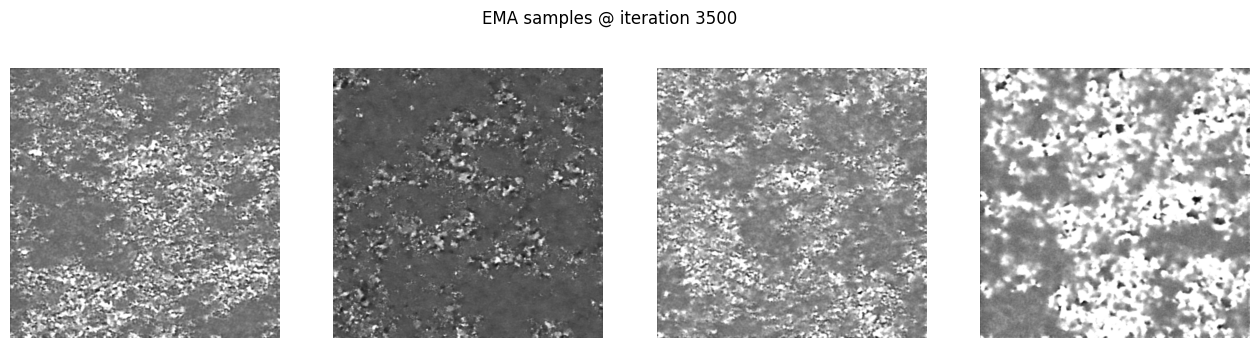

Saved checkpoint: /content/drive/MyDrive/az80_ddpm_outputs/checkpoints/ckpt_iter003500.pth.tar
[iter 3550/3600] loss=0.0246 elapsed=10.8 min
[iter 3600/3600] loss=0.0177 elapsed=11.4 min


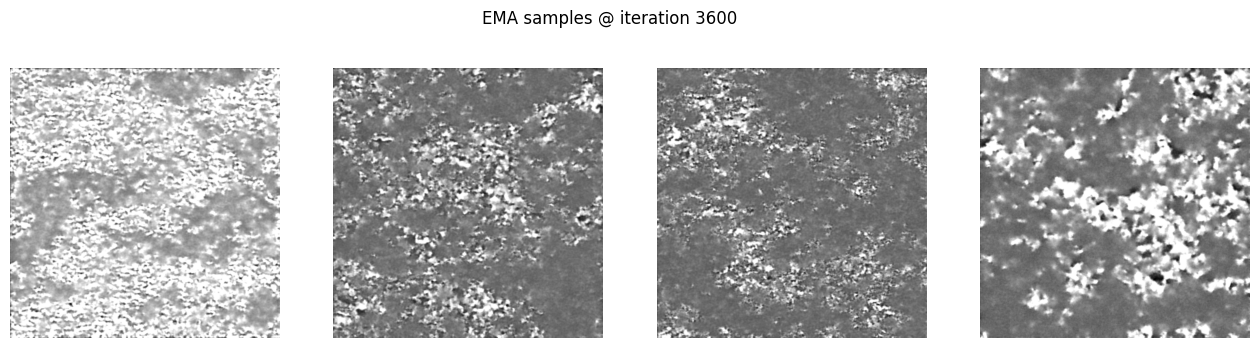

Saved checkpoint: /content/drive/MyDrive/az80_ddpm_outputs/checkpoints/ckpt_iter003600.pth.tar
Training finished after 3600 iterations.
|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 0            |        cudaMalloc retries: 0         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      |  10229 MiB |  12671 MiB |  27848 GiB |  27838 GiB |
|       from large pool |   9965 MiB |  12368 MiB |  27308 GiB |  27299 GiB |
|       from small pool |    263 MiB |    306 MiB |    539 GiB |    539 GiB |
|---------------------------------------------------------------------------|
| Acti

In [8]:
train_iter = itertools.cycle(train_loader)
running_loss = 0.0
start_time = time.time()

model.train()
pbar = tqdm(range(start_iteration, NUM_ITERATIONS + 1), initial=start_iteration - 1,
            total=NUM_ITERATIONS, desc='training')
for iteration in pbar:
    images, cond, _ = next(train_iter)
    images = images.to(device)
    shp, loc, cr, sk, ht, ft, mag = cond.to(device).unbind(dim=1)

    t = diffusion.sample_timesteps(images.shape[0]).to(device)
    x_t, noise = diffusion.noise_images(images, t)

    optimizer.zero_grad()
    with torch.amp.autocast('cuda', enabled=AMP_ENABLED):
        predicted_noise = model(x_t, t, shp, loc, cr, sk, ht, ft, mag)
        loss = mse(noise, predicted_noise)

    scaler.scale(loss).backward()
    scaler.step(optimizer)
    scaler.update()
    ema.step_ema(ema_model, model, step_start_ema=EMA_STEP_START)

    running_loss += loss.item()
    pbar.set_postfix(loss=loss.item())

    if iteration % LOG_EVERY == 0:
        elapsed_min = (time.time() - start_time) / 60
        print(f'[iter {iteration}/{NUM_ITERATIONS}] loss={running_loss / LOG_EVERY:.4f} elapsed={elapsed_min:.1f} min')
        running_loss = 0.0

    if iteration % SAMPLE_EVERY == 0 or iteration == NUM_ITERATIONS:
        model.eval()
        sample_and_show(ema_model, progress_conditions, title_prefix=f'EMA samples @ iteration {iteration}',
                         save_path=GENERATED_DIR / f'progress_iter{iteration:06d}.png')
        model.train()

    if iteration % CHECKPOINT_EVERY == 0 or iteration == NUM_ITERATIONS:
        ckpt_path = CHECKPOINT_DIR / f'ckpt_iter{iteration:06d}.pth.tar'
        save_checkpoint(ckpt_path, iteration)
        print(f'Saved checkpoint: {ckpt_path}')

print(f'Training finished after {NUM_ITERATIONS} iterations.')
if torch.cuda.is_available():
    print(torch.cuda.memory_summary(device=device))

## 7. Sampling and Evaluation

Generate new images from the trained (EMA) model for arbitrary process-parameter combinations, and visually compare a synthesized image against a real one for the same series -- for both a **seen** (training) and an **unseen** (held-out test) condition, mirroring the seen-vs-unseen comparison in Section 3 / Fig. 4 of the paper. This is a qualitative visual check; the paper's quantitative evaluation (FID score, DRX grain size, Mg₁₇Al₁₂ area fraction, Section 2.2.4) is out of scope for this notebook.

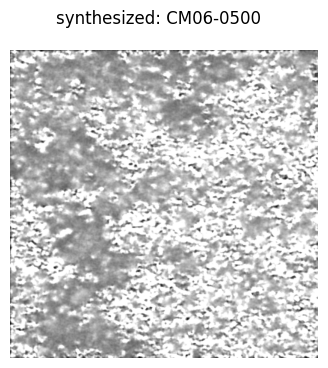

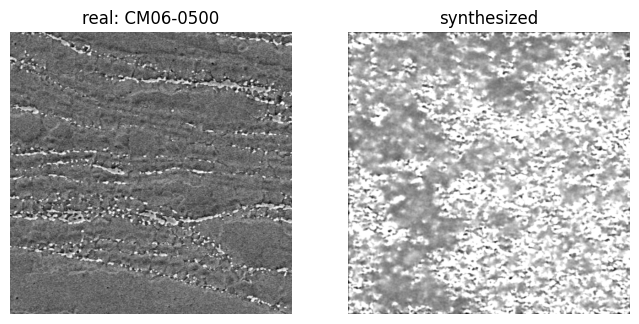

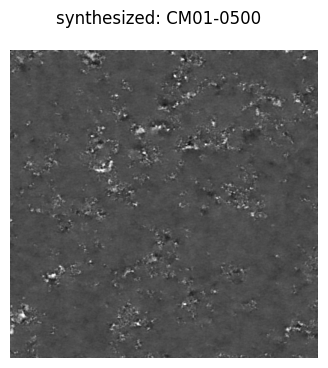

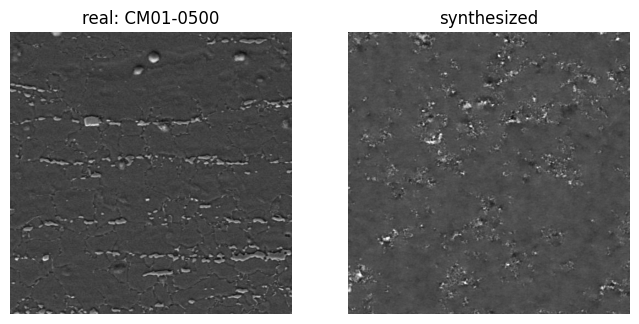

In [9]:
def compare_real_vs_synthesized(dataset: AZ80SeriesDataset, series_name: str = None, source_model=None):
    """dataset: train_dataset or test_dataset. series_name defaults to the
    first series that actually has images loaded in `dataset` -- a labels
    xlsx can list a series that has no corresponding uploaded images (e.g. a
    partially-populated dataset), so we pick from dataset.samples (built
    from what's really on disk) rather than dataset.label_table.index
    (built from the xlsx, which may list more series than were uploaded)."""
    source_model = source_model if source_model is not None else ema_model
    if series_name is None:
        series_name = dataset.samples[0][1]
    real_path = next((p for p, s in dataset.samples if s == series_name), None)
    if real_path is None:
        raise ValueError(
            f"No images found for series '{series_name}' in this dataset -- it "
            "may be listed in the labels xlsx but missing from the uploaded "
            "image folders."
        )
    real_image = transforms.Compose([
        transforms.Grayscale(),
        transforms.RandomCrop(IMAGE_SIZE, pad_if_needed=True, padding_mode='reflect'),
    ])(Image.open(real_path).convert('RGB'))

    row = dataset.label_table.loc[series_name]
    cond = {k: int(row[k]) for k in CONDITION_COLUMNS}
    synth = sample_and_show(source_model, [cond], title_prefix=f'synthesized: {series_name}')

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(real_image, cmap='gray')
    axes[0].set_title(f'real: {series_name}')
    axes[0].axis('off')
    axes[1].imshow(synth[0].squeeze(0).cpu(), cmap='gray')
    axes[1].set_title('synthesized')
    axes[1].axis('off')
    plt.show()


# Example: one unseen (held-out) condition, one seen (training) condition.
compare_real_vs_synthesized(test_dataset)
compare_real_vs_synthesized(train_dataset)

## 8. Final Save

Save the fully trained model, EMA model, and optimizer state to `models/`. The checkpoint format (`model_state`, `ema_model_state`, `model_optimizer` keys) matches what `load_model()` in `utils.py` / `image_generator.py` expects, so this file can be dropped directly into the original inference notebook / `image_generator.py`'s `load_dir`.

In [10]:
final_model_path = MODELS_DIR / 'az80_ddpm_final.pth.tar'
save_checkpoint(final_model_path, NUM_ITERATIONS)
print(f'Final model + EMA model + optimizer state saved to {final_model_path}')

Final model + EMA model + optimizer state saved to /content/drive/MyDrive/az80_ddpm_outputs/models/az80_ddpm_final.pth.tar
